<a href="https://colab.research.google.com/github/BastianRu/Deep-Learning-Foundations-From-Scratch-Journal/blob/main/01-Autograd_%26_MLP_from_Scratch/MLPFromScratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Installing micrograd
#pip install micrograd

#Or defining Value class

import math

class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0
        # internal variables used for autograd graph construction
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op # the op that produced this node, for graphviz / debugging / etc

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def tanh(self):
      x = self.data
      t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
      out = Value(t, (self, ), 'tanh')

      def _backward():
        self.grad += (1 - t**2) * out.grad
      out._backward = _backward

      return out

    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"


In [ ]:
#from micrograd.engine import Value
import random

#Defining Neuron, Layer and MLP classes

class Neuron:
  #nin = number of inputs which is the same number of "neurons" of the input layer
  def __init__(self, nin: int):
    #nin weights since each neuron is fed with nin inputs
    self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1, 1)) #1 bias per neuron

  def __call__(self, x: list[float], activate: bool=True):
    pre_act = sum((xi*wi for xi, wi in zip(self.w, x)), self.b) #this is X*W + b (dot product)
    act = pre_act.tanh() #we're going to use ReLU function for non-linearilty this time
    return act

class Layer:
  #nin is still the same, nouts is the number of outpus of the layer, which is the same number of neurons for the layer
  def __init__(self, nin: int, nouts: int):
    #each neuron is fed with nin inputs
    self.neurons = [Neuron(nin) for _ in range(nouts)]

  def __call__(self, x: list[float], activate: bool):
    #for each neuron we feed it with the data
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

class MLP:
  #instead of a single number, now we're going to have a list of numbers which represents number of neurons for each layer
  def __init__(self, nin:int, anouts: list[int]):
    sz = [nin] + anouts
    #here're some intereting things happening
    #we've summed up nin + array of outs (anouts). Theorically we want that because we want to iterate over each element
    #in order to yield a Layer for each one, however, look that we're not using len(sz) to get the range, we're using anouts length
    #and that's because we don't want the last layer to be a hidden (intermidiate) layer, we just want it to be an ouput, in code
    #we substract 1 to the for, and that's all
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(anouts))]

  def parameters(self):
    params = []
    for lyr in self.layers:
      for n in lyr.neurons:
        params.extend(n.w)
        params.append(n.b)
    return params

  def __call__(self, x):
    #here's another awesome logic
    #in i = 0, x is the input (first layer), but after...i = 1, 2, 3...
    #x is updated with the outputs from the previous layers
    #in the end, i = len(anouts), the call function returns the final MLP output...
    #If it's the last layer, the neurons output has no activation
    for i, lyr in enumerate(self.layers):
      x = lyr(x, activate=(i != len(self.layers)-1))
    return x


In [ ]:
#Testing the MLP (SIMPLE)

x = [3, 4, 5] #input
test_MLP = MLP(3, [4, 4, 1])
out = test_MLP(x)
out

Value(data=-0.6846832893940192, grad=0)

In [ ]:
#More complex examples

#gate predicting MLP
#gMLP = MLP(2, [2, 2, 1])

#OR gate
"""
x = [[1, 0], [0, 1], [0, 0], [1, 1]] #inputs
ys = [1, 1, 0, 1] #expected outpus
"""
#XOR gate

#x = [[1, 0], [0, 1], [0, 0], [1, 1]] #inputs
#ys = [1, 1, 0, 0] #expected outpus


#first prediction
#ypreds = [gMLP(xi) for xi in x]
#ypreds

'\nx = [[1, 0], [0, 1], [0, 0], [1, 1]] #inputs\nys = [1, 1, 0, 1] #expected outpus\n'

In [ ]:
#Predicting y = sen(x)

senMLP = MLP(1, [4, 4, 1])

x = [ [random.uniform(-math.pi, math.pi)] for _ in range(50)]
ys = [math.sin(xi[0]) for xi in x]

ypreds = [senMLP(xi) for xi in x]


In [ ]:
[ f"x: {xi[0]} / y: {ysi}" for xi, ysi in zip(x, ys) ][:5]

['x: 1.5244028488297552 / y: 0.9989240156135998',
 'x: 1.3085708938611997 / y: 0.9658154700327606',
 'x: 1.0492276904646998 / y: 0.867038688074951',
 'x: -1.7437137797575937 / y: -0.9850869916491657',
 'x: -1.105417596889418 / y: -0.8936516703823278']

In [ ]:
#defining a train cycle

#loss data list for plotting
loss_d = []

def trainMLP(mlp: MLP, ephocs: int, ephoc_skip: int):
  plotrange = ephocs
  for i in range(ephocs):
    #forward pass
    ypreds = [mlp(xi) for xi in x]

    #loss
    loss = sum((ypredsi - ysi)**2 for ypredsi, ysi in zip(ypreds, ys))
    if i%ephoc_skip == 0: print(f"Ephoc: {i} / Loss = {loss.data}")
    if i == ephocs-1: print(f"Ephoc: {i} / Loss = {loss.data}")
    loss_d.append(loss.data)

    #backward pass
    params = mlp.parameters()
      #set gradient to 0, very important!
    for param in params:
      param.grad = 0
    loss.backward()

    #gradient descent
    for param in params:
      param.data += -0.001*param.grad

trainMLP(senMLP, 100, 10)




Ephoc: 0 / Loss = 24.221963334116538
Ephoc: 10 / Loss = 4.487218422746942
Ephoc: 20 / Loss = 3.1141937650915232
Ephoc: 30 / Loss = 2.6653930905241445
Ephoc: 40 / Loss = 2.474026379335508
Ephoc: 50 / Loss = 2.379284320078206
Ephoc: 60 / Loss = 2.326984985468798
Ephoc: 70 / Loss = 2.295282925820511
Ephoc: 80 / Loss = 2.2742744139619746
Ephoc: 90 / Loss = 2.259084162863659
Ephoc: 99 / Loss = 2.2482542884734196


In [ ]:
#Results

ypreds = [senMLP([3.141516])]
ypreds


[Value(data=0.7810242056298113, grad=0)]

Text(0, 0.5, 'Loss')

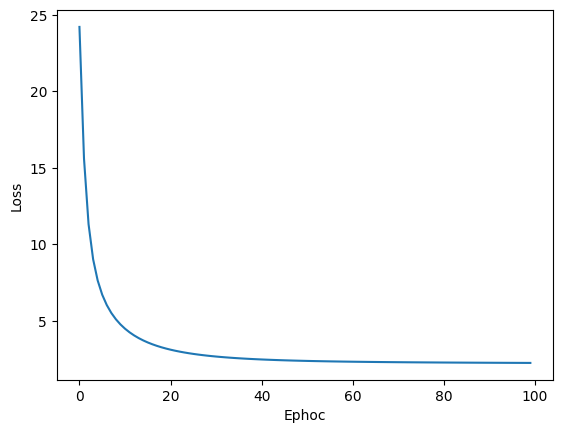

In [ ]:
import matplotlib.pyplot as plt

#Ephoc vs Loss

plt.plot(range(100), loss_d)
plt.xlabel("Ephoc") ; plt.ylabel("Loss")
